# 02 — Validate Skeleton Outputs

Run after skeleton extraction. It checks count, shapes, quality, and sample visualization.

In [1]:
from pathlib import Path
import os, random, time, gc, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

EXP_DIR = Path('/media/wadud/DriveUbuntu/GaitRecognition 2.0')
POSE_TAG = None  # None = auto-detect folder under data/poses with most .npz files
POSES_DIR = EXP_DIR / 'data' / 'poses'
SPLIT_DIR = EXP_DIR / 'data' / 'splits'
REPORT_DIR = EXP_DIR / 'data' / 'reports'
RESULT_DIR = EXP_DIR / 'results'
CHECKPOINT_DIR = EXP_DIR / 'checkpoints'
LOG_DIR = EXP_DIR / 'logs'
for d in [SPLIT_DIR, REPORT_DIR, RESULT_DIR, CHECKPOINT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def detect_pose_root(poses_dir=POSES_DIR, pose_tag=POSE_TAG):
    if pose_tag is not None:
        root = poses_dir / pose_tag
        if not root.exists():
            raise FileNotFoundError(root)
        return root
    candidates = [p for p in poses_dir.iterdir() if p.is_dir()] if poses_dir.exists() else []
    if not candidates:
        raise FileNotFoundError(f'No pose folders under {poses_dir}')
    counts = sorted([(len(list(p.rglob('*.npz'))), p) for p in candidates], reverse=True, key=lambda x: x[0])
    return counts[0][1]

POSE_ROOT = detect_pose_root()
print('EXP_DIR  :', EXP_DIR)
print('POSE_ROOT:', POSE_ROOT)

EXP_DIR  : /media/wadud/DriveUbuntu/GaitRecognition 2.0
POSE_ROOT: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/poses/yolo26l_pose


In [2]:
EXPECTED = 124*10*11
pose_files = sorted(POSE_ROOT.rglob('*.npz'))
print('Pose files:', len(pose_files), 'Expected:', EXPECTED)
if not pose_files: raise RuntimeError('No pose files found.')
summary_csv = REPORT_DIR / 'skeleton_extraction_summary.csv'
if summary_csv.exists():
    df_sum = pd.read_csv(summary_csv); display(df_sum['status'].value_counts()); display(df_sum.head())
else:
    print('No extraction summary found:', summary_csv)

Pose files: 13640 Expected: 13640


status
ok                13635
skipped_exists        5
Name: count, dtype: int64

,status,video_path,out_npz,subject,condition,seq,view,fps,width,height,frame_count_cv2,frame_count_processed,valid_frame_ratio,mean_kpt_score,mean_det_score,error
0,skipped_exists,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,skipped_exists,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,1,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,skipped_exists,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,1,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,skipped_exists,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,1,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,skipped_exists,/media/wadud/DriveUbuntu/CASIA/Main/DatasetB/v...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,1,bg,1,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
rows=[]
for p in tqdm(pose_files, desc='Checking pose files'):
    try:
        data=np.load(p); X=data['keypoints_norm_filled']; scores=data['scores']; valid=data['frame_valid']
        rel=p.relative_to(POSE_ROOT); subject=rel.parts[0]; condition,seq=rel.parts[1].split('-'); view=p.stem
        rows.append({'pose_path':str(p),'subject':subject,'condition':condition,'seq':seq,'view':view,'frames':X.shape[0],
                     'shape_ok':X.ndim==3 and X.shape[1:]==(17,2),'valid_frame_ratio':float(valid.mean()),
                     'mean_kpt_score':float(np.nanmean(scores))})
    except Exception as e:
        rows.append({'pose_path':str(p),'shape_ok':False,'valid_frame_ratio':0,'mean_kpt_score':0,'error':str(e)})
df=pd.DataFrame(rows); out=REPORT_DIR/'pose_quality_report.csv'; df.to_csv(out,index=False)
print('Saved:',out); display(df[['frames','valid_frame_ratio','mean_kpt_score']].describe()); display(df.head())
low=df[(df['shape_ok']!=True)|(df['valid_frame_ratio']<0.70)|(df['mean_kpt_score']<0.30)]
low_out=REPORT_DIR/'low_quality_pose_files.csv'; low.to_csv(low_out,index=False)
print('Low quality:',len(low),'Saved:',low_out); display(low.head(20))

Checking pose files:   0%|          | 0/13640 [00:00<?, ?it/s]

Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/pose_quality_report.csv


,frames,valid_frame_ratio,mean_kpt_score
count,13640.000000,13640.000000,13640.000000
mean,120.973974,0.797263,0.653485
std,21.729111,0.151629,0.168097
min,12.000000,0.000000,0.000000
25%,106.000000,0.672000,0.509307
50%,119.000000,0.800000,0.629716
75%,134.000000,0.937500,0.781472
max,311.000000,1.000000,0.970498


,pose_path,subject,condition,seq,view,frames,shape_ok,valid_frame_ratio,mean_kpt_score
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,000,99,True,1.000000,0.942729
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,018,102,True,1.000000,0.909530
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,036,99,True,0.919192,0.817031
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,054,106,True,0.915094,0.754640
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,072,106,True,0.707547,0.544844


Low quality: 4217 Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/reports/low_quality_pose_files.csv


,pose_path,subject,condition,seq,view,frames,shape_ok,valid_frame_ratio,mean_kpt_score
5,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,090,106,True,0.669811,0.488305
15,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,02,072,116,True,0.637931,0.498538
16,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,02,090,114,True,0.622807,0.453924
17,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,02,108,116,True,0.646552,0.466491
18,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,02,126,113,True,0.672566,0.492222
27,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,cl,01,090,100,True,0.630000,0.468159
28,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,cl,01,108,98,True,0.642857,0.470553
29,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,cl,01,126,98,True,0.663265,0.488924
30,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,cl,01,144,102,True,0.656863,0.484381
48,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,nm,01,072,101,True,0.693069,0.553531


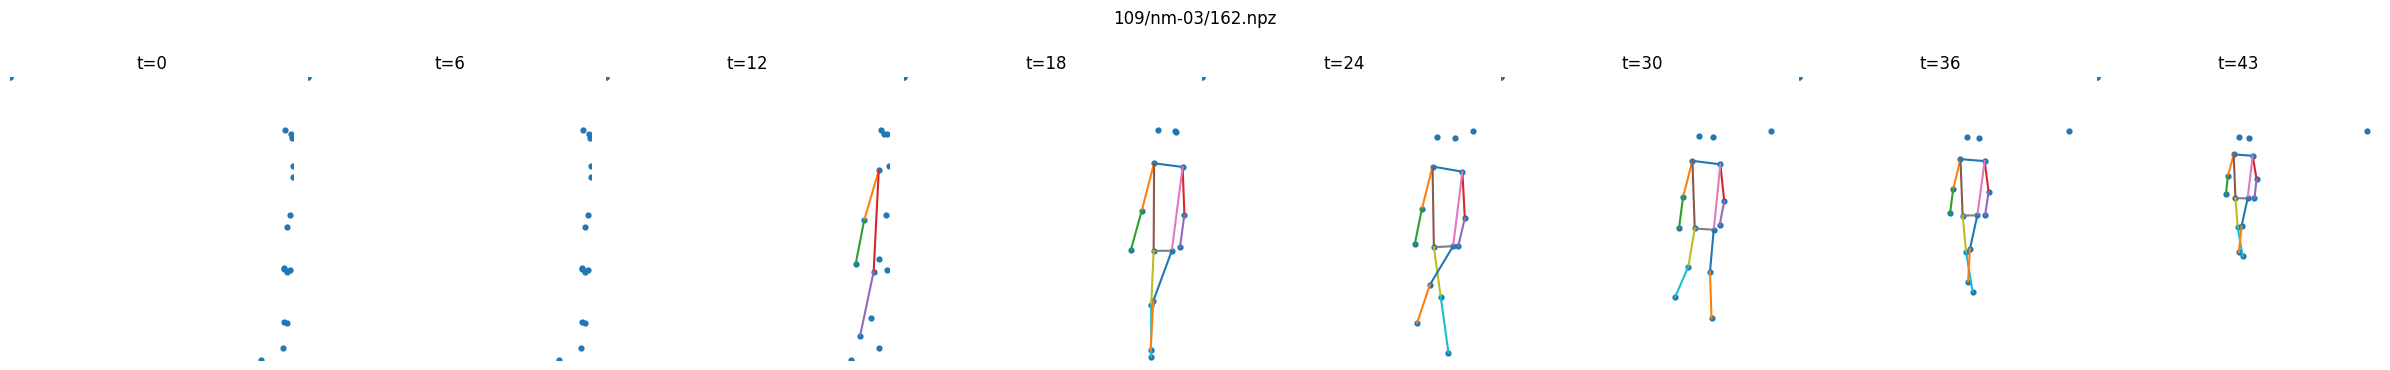

In [4]:
COCO_EDGES=[(0,1),(0,2),(1,3),(2,4),(5,6),(5,7),(7,9),(6,8),(8,10),(5,11),(6,12),(11,12),(11,13),(13,15),(12,14),(14,16)]
def plot_sample(npz_path):
    data=np.load(npz_path); X=data['keypoints_norm_filled']; scores=data['scores']; T=X.shape[0]
    ids=np.linspace(0,T-1,num=min(8,T)).astype(int)
    fig,axes=plt.subplots(1,len(ids),figsize=(3*len(ids),4));
    if len(ids)==1: axes=[axes]
    for ax,t in zip(axes,ids):
        pts=X[t]; conf=scores[t]
        for a,b in COCO_EDGES:
            if conf[a]>=0.2 and conf[b]>=0.2: ax.plot([pts[a,0],pts[b,0]],[pts[a,1],pts[b,1]])
        ax.scatter(pts[:,0],pts[:,1],s=12); ax.set_xlim(0,1); ax.set_ylim(1,0); ax.set_aspect('equal'); ax.axis('off'); ax.set_title(f't={t}')
    fig.suptitle(str(npz_path.relative_to(POSE_ROOT))); plt.tight_layout(); plt.show()
plot_sample(random.choice(pose_files))

In [5]:
pose_files = sorted(POSE_ROOT.rglob("*.npz"))

print("Total pose files:", len(pose_files))
print("Expected:", 13640)

Total pose files: 13640
Expected: 13640
